In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pycountry
from scipy import stats
from scipy.signal import savgol_filter


In [5]:
# Cargar datos de proyeccion PIB
Proyeccion_PIB = '../../data/fuentes/economicos/Proyeccion_PIB_indicepais.xlsx'
df_proyPib = pd.read_excel(Proyeccion_PIB, sheet_name='Impacto en PIB')

# Mostrar las primeras filas y la información del dataset
print("Proyeccion impacto en PIB:")
print(f"Dimensiones: {df_proyPib.shape}")
print("\nPrimeras filas:")
display(df_proyPib.head())
print("\nInformación del dataset:")
display(df_proyPib.info())
print("\nColumnas disponibles:")
display(df_proyPib.columns.tolist())
print("\nEstadisticas")
display(df_proyPib.describe())

Proyeccion impacto en PIB:
Dimensiones: (232, 5)

Primeras filas:


,Pais/ Region,Sin incremento en desastres,Mediano incremento en desastres (x5),Extremo incremento en desastres (x10),Escenario incremento T°
0,World,"–0,5%","–2,2%","–4,2%",Incremento bajo 2°C (Acuerdo París)
1,OECD,"–0,4%","–1,6%","–3,1%",Incremento bajo 2°C (Acuerdo París)
2,North America,"–0,5%","–1,7%","–3,1%",Incremento bajo 2°C (Acuerdo París)
3,South America,"–0,4%","–2,0%","–4,1%",Incremento bajo 2°C (Acuerdo París)
4,Europe,"–0,2%","–1,4%","–2,8%",Incremento bajo 2°C (Acuerdo París)



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Pais/ Region                           232 non-null    object
 1   Sin incremento en desastres            232 non-null    object
 2   Mediano incremento en desastres (x5)   232 non-null    object
 3   Extremo incremento en desastres (x10)  232 non-null    object
 4   Escenario incremento T°                232 non-null    object
dtypes: object(5)
memory usage: 9.2+ KB


None


Columnas disponibles:


['Pais/ Region',
 'Sin incremento en desastres',
 'Mediano incremento en desastres (x5)',
 'Extremo incremento en desastres (x10)',
 'Escenario incremento T°']


Estadisticas


,Pais/ Region,Sin incremento en desastres,Mediano incremento en desastres (x5),Extremo incremento en desastres (x10),Escenario incremento T°
count,232,232,232,232,232
unique,58,56,110,145,4
top,World,"–0,9%","–4,0%","–3,1%",Incremento bajo 2°C (Acuerdo París)
freq,4,16,7,5,58


In [6]:
display(df_proyPib.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Pais/ Region                           232 non-null    object
 1   Sin incremento en desastres            232 non-null    object
 2   Mediano incremento en desastres (x5)   232 non-null    object
 3   Extremo incremento en desastres (x10)  232 non-null    object
 4   Escenario incremento T°                232 non-null    object
dtypes: object(5)
memory usage: 9.2+ KB


None

In [7]:
#Trasponer columnas de escenarios para poder graficar

df_proyPibtras=df_proyPib.melt(
    id_vars = ["Pais/ Region", "Escenario incremento T°"],
    value_vars= [
        "Sin incremento en desastres",
        "Mediano incremento en desastres (x5)",
        "Extremo incremento en desastres (x10)"
    ],

    var_name= "Escenario desastres",
    value_name= "Impacto en PIB"
)

# Transformar en formato número para poder graficar

df_proyPibtras["Impacto en PIB"] = (
        df_proyPibtras["Impacto en PIB"].astype(str)
        .str.replace("–", "-", regex=False)           
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)

)

df_proyPibtras["Impacto en PIB"]=pd.to_numeric(df_proyPibtras["Impacto en PIB"], errors="coerce")

display(df_proyPibtras.info())

print(df_proyPibtras.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Pais/ Region             696 non-null    object 
 1   Escenario incremento T°  696 non-null    object 
 2   Escenario desastres      696 non-null    object 
 3   Impacto en PIB           696 non-null    float64
dtypes: float64(1), object(3)
memory usage: 21.9+ KB


None

           Pais/ Region              Escenario incremento T°  \
0                 World  Incremento bajo 2°C (Acuerdo París)   
1                  OECD  Incremento bajo 2°C (Acuerdo París)   
2         North America  Incremento bajo 2°C (Acuerdo París)   
3         South America  Incremento bajo 2°C (Acuerdo París)   
4                Europe  Incremento bajo 2°C (Acuerdo París)   
5  Middle East & Africa  Incremento bajo 2°C (Acuerdo París)   
6                  Asia  Incremento bajo 2°C (Acuerdo París)   
7         Advanced Asia  Incremento bajo 2°C (Acuerdo París)   
8                 ASEAN  Incremento bajo 2°C (Acuerdo París)   
9               Oceania  Incremento bajo 2°C (Acuerdo París)   

           Escenario desastres  Impacto en PIB  
0  Sin incremento en desastres            -0.5  
1  Sin incremento en desastres            -0.4  
2  Sin incremento en desastres            -0.5  
3  Sin incremento en desastres            -0.4  
4  Sin incremento en desastres            -0.2  
5

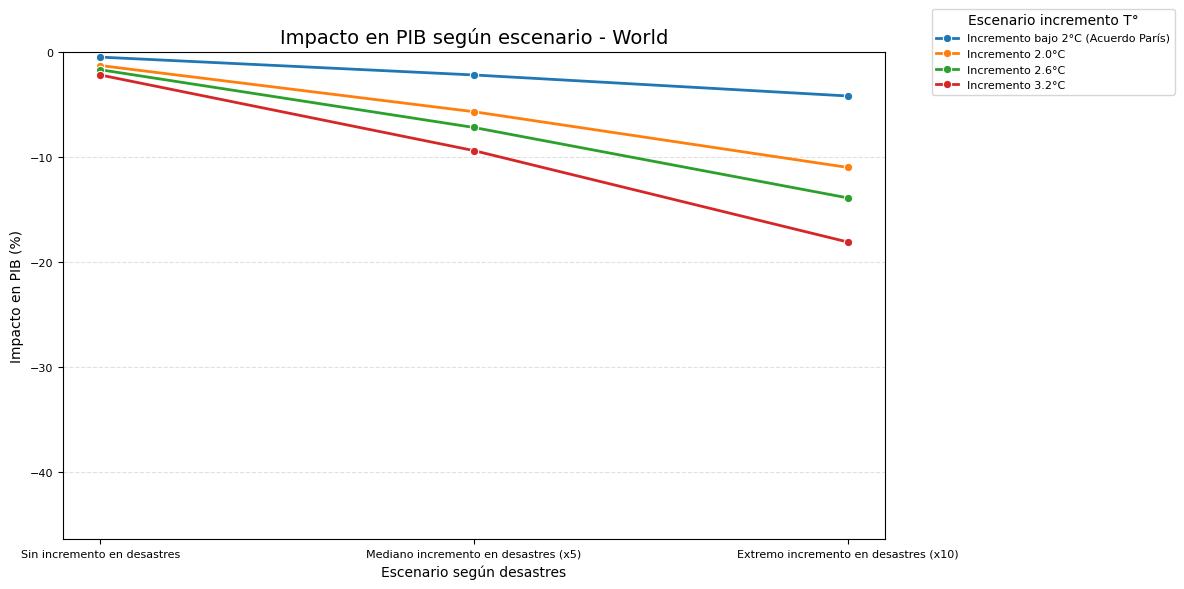

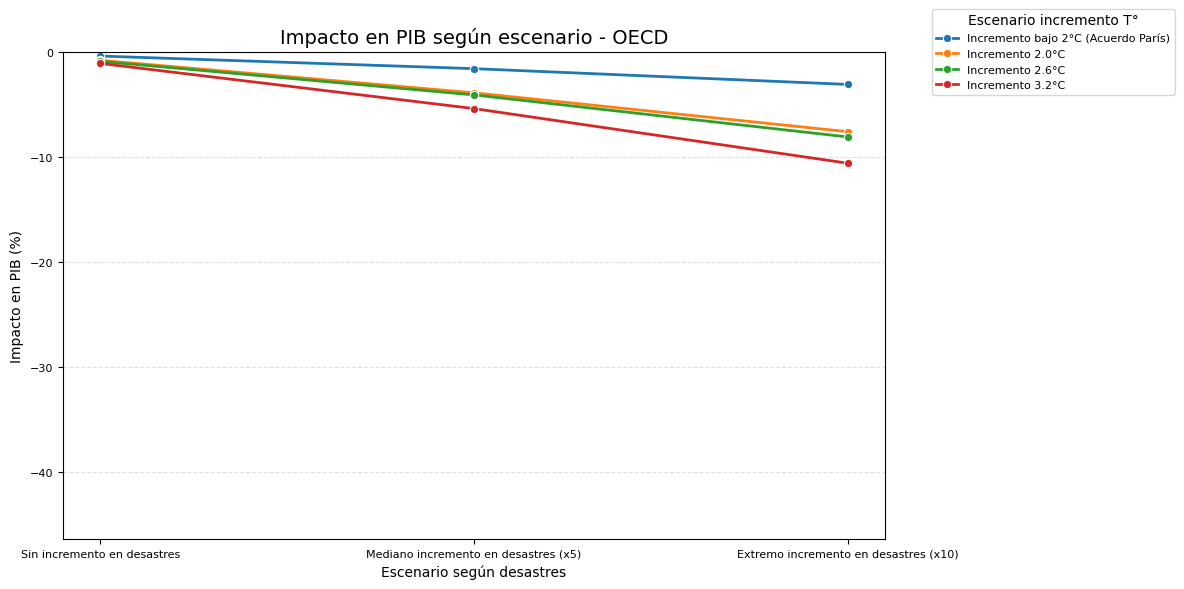

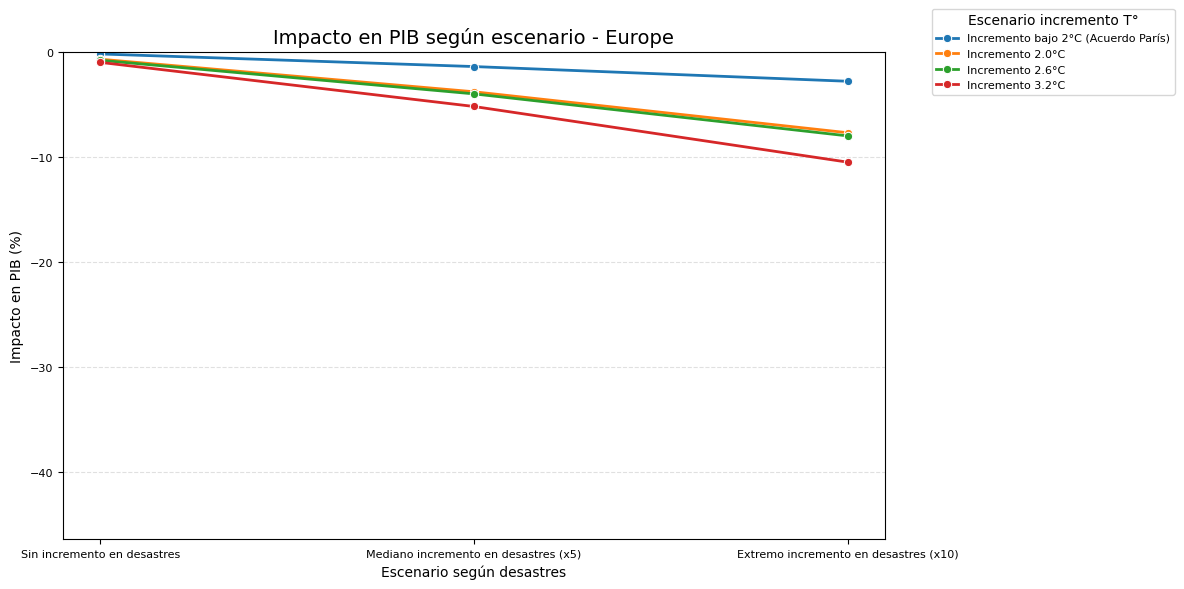

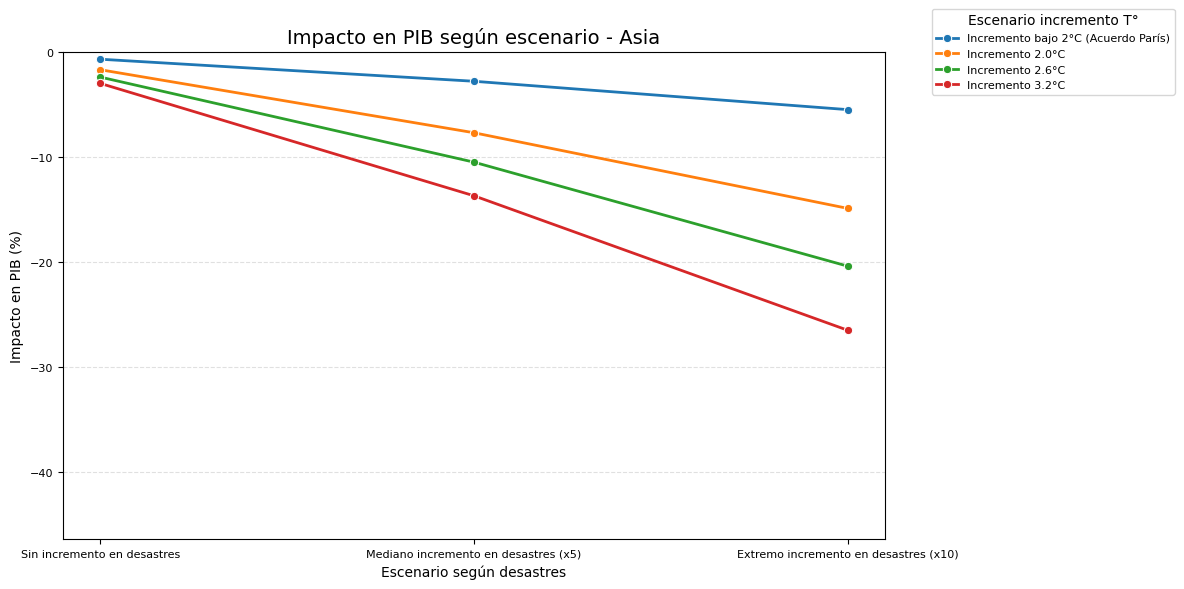

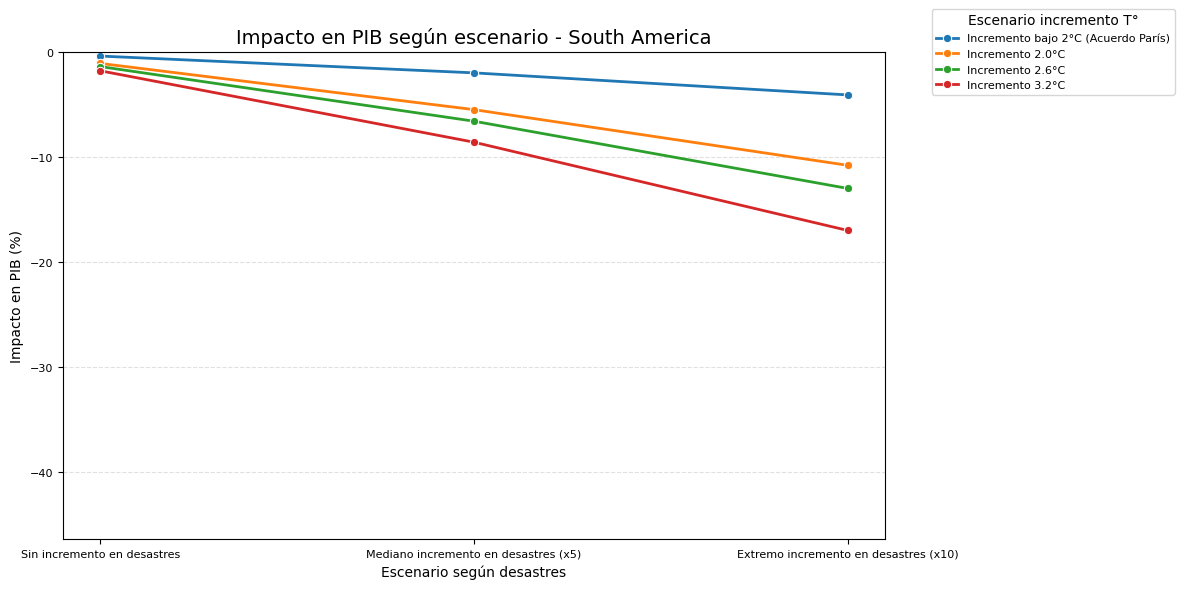

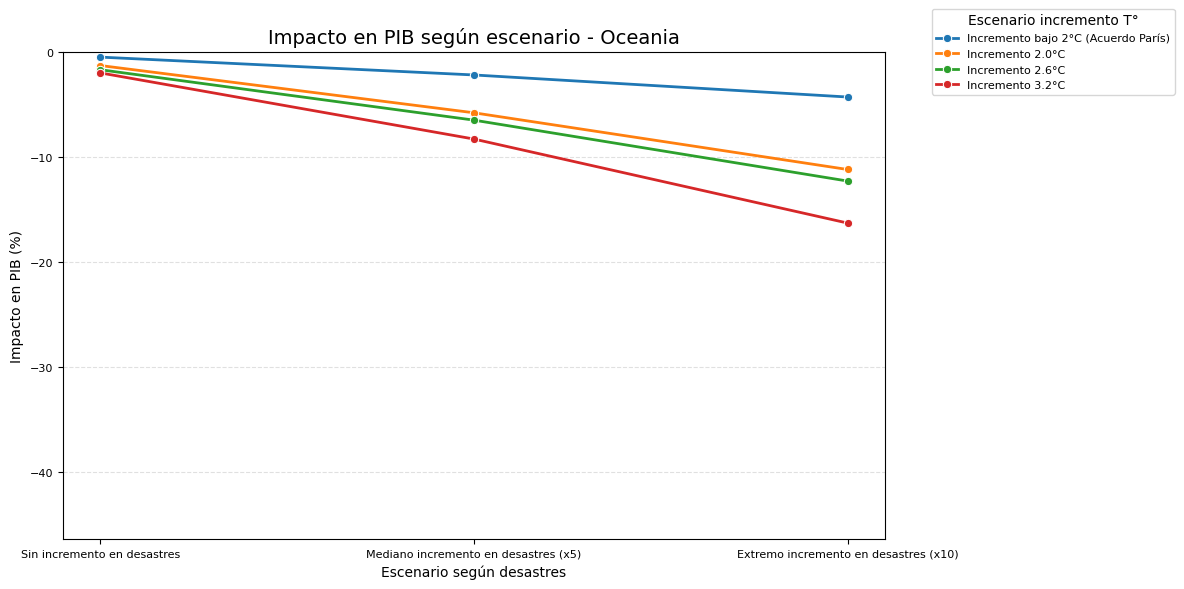

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecciona 6 regiones que quieras mostrar
regiones = ["World", "OECD", "Europe", "Asia", "South America", "Oceania"]

# Determinar el rango global del eje Y (mínimo y máximo de todos los datos)
ymin = df_proyPibtras["Impacto en PIB"].min()
ymax = df_proyPibtras["Impacto en PIB"].max()

for region in regiones:
    df_region = df_proyPibtras[df_proyPibtras["Pais/ Region"] == region]

    plt.figure(figsize=(12,6))
    
    sns.lineplot(
        data=df_region,
        x="Escenario desastres",
        y="Impacto en PIB",
        hue="Escenario incremento T°",
        marker="o",
        linewidth=2
    )

    # Título dinámico
    plt.title(f"Impacto en PIB según escenario - {region}", fontsize=14)
    plt.ylabel("Impacto en PIB (%)", fontsize=10)
    plt.xlabel("Escenario según desastres", fontsize=10)

    # Escala uniforme en eje Y
    plt.ylim(ymin, ymax)

    # Estilo de ticks y grillas
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.grid(axis="x", visible=False)
    plt.grid(axis="y", visible=True, linestyle="--", color="#d3d3d3", alpha=0.7)

    # Leyenda
    plt.legend(
        title="Escenario incremento T°",
        bbox_to_anchor=(1.05, 1),
        fontsize=8,
        loc="center left"
    )

    plt.tight_layout()
    plt.show()


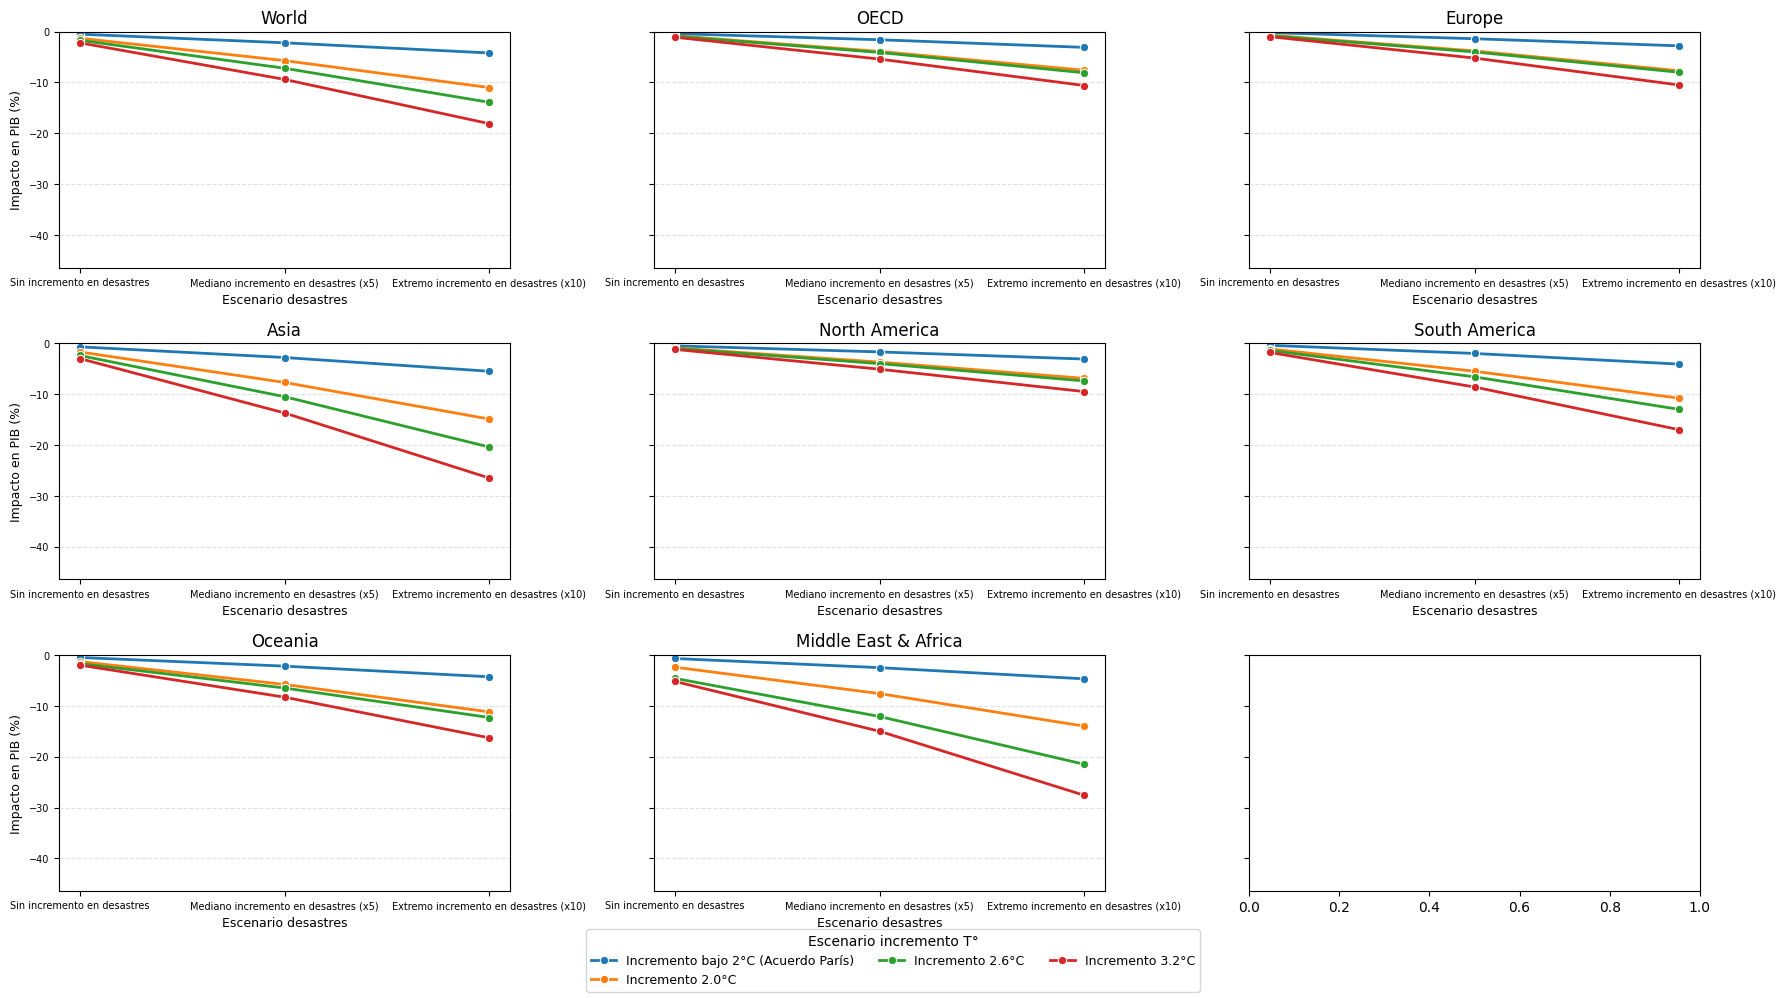

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecciona cada región
regiones = ["World", "OECD", "Europe", "Asia", "North America", "South America", "Oceania", "Middle East & Africa"]

# Determinar rango global de Y
ymin = df_proyPibtras["Impacto en PIB"].min()
ymax = df_proyPibtras["Impacto en PIB"].max()

# Crear figura con 2 filas x 3 columnas
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

# Variable para guardar leyenda global
handles, labels = None, None

for i, region in enumerate(regiones):
    df_region = df_proyPibtras[df_proyPibtras["Pais/ Region"] == region]

    ax = sns.lineplot(
        data=df_region,
        x="Escenario desastres",
        y="Impacto en PIB",
        hue="Escenario incremento T°",
        marker="o",
        linewidth=2,
        ax=axes[i]
    )

    # Solo guardamos los handles/labels de la primera iteración
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    # Quitamos leyenda de cada subplot
    ax.get_legend().remove()

    # Personalización de cada subplot
    axes[i].set_title(region, fontsize=12)
    axes[i].set_xlabel("Escenario desastres", fontsize=9)
    axes[i].set_ylabel("Impacto en PIB (%)", fontsize=9)
    axes[i].set_ylim(ymin, ymax)
    axes[i].tick_params(axis="x", labelsize=7)
    axes[i].tick_params(axis="y", labelsize=7)
    axes[i].grid(axis="x", visible=False)
    axes[i].grid(axis="y", visible=True, linestyle="--", color="#d3d3d3", alpha=0.7)

# ✅ Agregamos la leyenda global usando los handles/labels guardados
fig.legend(
    handles, labels,
    title="Escenario incremento T°",
    loc="lower center",
    fontsize=9,
    title_fontsize=10,
    ncol=3
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # espacio para la leyenda abajo
plt.show()




In [12]:
# Filtra escenario de desastres x5 y calentamiento 2.6°C
df_filtro = df_proyPibtras[
    (df_proyPibtras["Escenario desastres"] == "Mediano incremento en desastres (x5)") &
    (df_proyPibtras["Escenario incremento T°"] == "Incremento 2.6°C")
]

# Ordena por Impacto en PIB (de menor pérdida a mayor) y tomar top 10
top10_menores_perdidas = df_filtro.sort_values(by="Impacto en PIB", ascending=False).head(10)

# Muestra columnas relevantes
print(top10_menores_perdidas[["Pais/ Region", "Impacto en PIB"]])


    Pais/ Region  Impacto en PIB
368      Denmark            -1.1
403      Ukraine            -1.3
397  Switzerland            -1.8
370      Finland            -1.8
360      Austria            -2.3
382  Netherlands            -2.3
384       Norway            -2.6
396       Sweden            -2.8
361      Belgium            -2.9
402           UK            -3.1


In [45]:
# Filtra escenario de desastres x5 y calentamiento 2.6°C
df_filtro = df_proyPibtras[
    (df_proyPibtras["Escenario desastres"] == "Mediano incremento en desastres (x5)") &
    (df_proyPibtras["Escenario incremento T°"] == "Incremento 2.6°C")
]

# Ordena por Impacto en PIB (de menor pérdida a mayor) y toma los peores 10
top10_mayores_perdidas = df_filtro.sort_values(by="Impacto en PIB", ascending=True).head(10)

# Muestra columnas relevantes
print(top10_mayores_perdidas[["Pais/ Region", "Impacto en PIB"]])


     Pais/ Region  Impacto en PIB
380      Malaysia           -20.1
386   Philippines           -19.5
391  Saudi Arabia           -19.4
392     Singapore           -18.6
399      Thailand           -17.8
377     Indonesia           -15.4
376         India           -13.9
401           UAE           -13.3
398        Taiwan           -11.3
364         Chile           -10.8


In [47]:
df_proyPibtras.describe()

,Impacto en PIB,indicador_id,anio
count,588.000000,588.000000,588.0
mean,-6.137378,31.500000,2024.0
std,7.399644,3.454992,0.0
min,-46.400000,26.000000,2024.0
25%,-8.225000,28.750000,2024.0
50%,-3.700000,31.500000,2024.0
75%,-1.300000,34.250000,2024.0
max,0.004000,37.000000,2024.0


In [1]:
import pymysql
from pymysql.constants import CLIENT
import os
from dotenv import load_dotenv

# Cargar credenciales desde .env
load_dotenv()
DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

# Conectar
conexion = pymysql.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME,
    client_flag=CLIENT.MULTI_STATEMENTS
)
cursor = conexion.cursor()

# 1) Insertar continente con ID = 0 (si no existe)
sql_insert_continente = """
INSERT IGNORE INTO continentes (id, nombre)
VALUES (0, 'World');
"""
cursor.execute(sql_insert_continente)

# 2) Insertar país "World"
valores = [
    ("WO", "World", "World", 0)
]
sql_insert_paises = """
INSERT INTO paises (codigo, nombre, nombre_en, continente_id)
VALUES (%s, %s, %s, %s)
"""
cursor.executemany(sql_insert_paises, valores)

# Confirmar cambios
conexion.commit()

print(f"✅ Se insertó el continente y {cursor.rowcount} registro(s) en la tabla Paises.")

# Cerrar conexión
cursor.close()
conexion.close()


✅ Se insertó el continente y 1 registro(s) en la tabla Paises.


In [31]:
import pandas as pd
import numpy as np
import pymysql
from pymysql.constants import CLIENT
from dotenv import load_dotenv
import os

load_dotenv()

# Obtener los parámetros de conexión
DB_HOST = os.getenv('DB_HOST')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_NAME = os.getenv('DB_NAME')

conexion = pymysql.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME,
    client_flag=CLIENT.MULTI_STATEMENTS
)
cursor = conexion.cursor()

# 2) Cargar dimensión Paises: (codigo, nombre_en) → dict nombre_en_normalizado → codigo
cursor.execute("SELECT codigo, nombre_en FROM Paises;")
dim_paises = {
    nombre_en.strip().lower(): codigo
    for codigo, nombre_en in cursor.fetchall()
}



# 1) Normalizar columna "Pais/ Region" → minúsculas y sin espacios
df_proyPibtras["pais_norm"] = (
    df_proyPibtras["Pais/ Region"]
      .astype(str)
      .str.strip()
      .str.lower()
)

# 2) Diccionario de excepciones (adaptado a tus datos)
exceptions = {
    'netherlands':'netherlands (kingdom of the)',
    'turkiye':'türkiye',
    'united kingdom':'united kingdom of great britain and northern ireland',
    'bahamas, the':'bahamas',
    'bolivia':'bolivia (plurinational state of)',
    'congo, dem. rep.':'congo (the democratic republic of the)',
    'congo, rep.':'congo',
    "cote d'ivoire":"côte d'ivoire",
    'egypt, arab rep.':'egypt',
    'gambia, the':'gambia',
    'hong kong sar, china':'hong kong',
    'iran, islamic rep.':'iran (islamic republic of)',
    'korea, rep.':'korea (the republic of)',
    'micronesia, fed. states of':'micronesia (federated states of)',
    'st. vincent and the grenadines':'saint vincent and the grenadines',
    'tanzania':'tanzania, the united republic of',
    'curacao':'curaçao',
    "korea, dem. people's rep.":"korea (the democratic people's republic of)",
    'slovak republic':'slovakia',
    'venezuela, rb':'venezuela (bolivarian republic of)',
    'yemen, rep.':'yemen',
    'st. kitts and nevis':'saint kitts and nevis',
    'st. lucia':'saint lucia',
    'macao sar, china':'macao',
    'lao pdr':"lao people's democratic republic",
    'kyrgyz republic':'kyrgyzstan',
    'russian federation':'russian federation',
    'moldova':'moldova (the republic of)',
    'united states':'united states of america',
    'us':'united states of america',
    'st. martin (french part)':'saint martin (french part)',
    'british virgin islands':'virgin islands (british)',
    'venezuela':'Venezuela (Bolivarian Republic of)',
    'south korea':'Korea (the Republic of)',
    'czech republic': 'Czechia',
    'russia': 'Russian Federation',
    'taiwan': 'Taiwan (Province of China)',
    'turkey': 'Türkiye',
    'uae': 'United Arab Emirates',
    'uk': 'United Kingdom of Great Britain and Northern Ireland',   

}

# 3) Aplicar excepciones → columna intermedia
df_proyPibtras["pais_db"] = df_proyPibtras["pais_norm"].map(
    lambda x: exceptions[x] if x in exceptions else x
)

# 4) Mapear con la dimensión de países cargada previamente
# (asegúrate de tener dim_paises = {nombre_en.lower(): codigo})
df_proyPibtras["pais_id"] = (
    df_proyPibtras["pais_db"]
      .str.strip()
      .str.lower()
      .map(dim_paises)
)

# 5) Listar países no mapeados
no_map = df_proyPibtras.loc[df_proyPibtras["pais_id"].isna(), "Pais/ Region"].unique()
print("⚠️ Países sin mapeo:", no_map)

df_proyPibtras

⚠️ Países sin mapeo: ['OECD' 'North America' 'South America' 'Europe' 'Middle East & Africa'
 'Asia' 'Advanced Asia' 'ASEAN' 'Oceania']


,Pais/ Region,Escenario incremento T°,Escenario desastres,Impacto en PIB,pais_norm,pais_db,pais_id
0,World,Incremento bajo 2°C (Acuerdo París),Sin incremento en desastres,-0.5,world,world,WO
1,OECD,Incremento bajo 2°C (Acuerdo París),Sin incremento en desastres,-0.4,oecd,oecd,NaN
2,North America,Incremento bajo 2°C (Acuerdo París),Sin incremento en desastres,-0.5,north america,north america,NaN
3,South America,Incremento bajo 2°C (Acuerdo París),Sin incremento en desastres,-0.4,south america,south america,NaN
4,Europe,Incremento bajo 2°C (Acuerdo París),Sin incremento en desastres,-0.2,europe,europe,NaN
...,...,...,...,...,...,...,...
691,UAE,Incremento 3.2°C,Extremo incremento en desastres (x10),-33.7,uae,United Arab Emirates,AE
692,UK,Incremento 3.2°C,Extremo incremento en desastres (x10),-8.7,uk,United Kingdom of Great Britain and Northern I...,GB
693,Ukraine,Incremento 3.2°C,Extremo incremento en desastres (x10),-5.6,ukraine,ukraine,UA
694,US,Incremento 3.2°C,Extremo incremento en desastres (x10),-9.2,us,united states of america,US


In [41]:
df_proyPibtras = df_proyPibtras.loc[df_proyPibtras["pais_id"].notna()].copy()


# Diccionario de mapeo: (Escenario T°, Escenario desastres) → indicador_id
indicadores_map = {
    ("Incremento bajo 2°C (Acuerdo París)", "Sin incremento en desastres"): 26,
    ("Incremento bajo 2°C (Acuerdo París)", "Mediano incremento en desastres (x5)"): 27,
    ("Incremento bajo 2°C (Acuerdo París)", "Extremo incremento en desastres (x10)"): 28,

    ("Incremento 2.0°C", "Sin incremento en desastres"): 29,
    ("Incremento 2.0°C", "Mediano incremento en desastres (x5)"): 30,
    ("Incremento 2.0°C", "Extremo incremento en desastres (x10)"): 31,

    ("Incremento 2.6°C", "Sin incremento en desastres"): 32,
    ("Incremento 2.6°C", "Mediano incremento en desastres (x5)"): 33,
    ("Incremento 2.6°C", "Extremo incremento en desastres (x10)"): 34,

    ("Incremento 3.2°C", "Sin incremento en desastres"): 35,
    ("Incremento 3.2°C", "Mediano incremento en desastres (x5)"): 36,
    ("Incremento 3.2°C", "Extremo incremento en desastres (x10)"): 37,
}


df_proyPibtras["indicador_id"] = df_proyPibtras.apply(
    lambda row: indicadores_map.get(
        (row["Escenario incremento T°"], row["Escenario desastres"])
    ),
    axis=1
)


# Crear columna año si corresponde (ejemplo: todos 2024, o derivado de otra variable)
df_proyPibtras["anio"] = 2020 

# Seleccionar columnas finales
df_hechos = df_proyPibtras[["anio", "Impacto en PIB", "pais_id", "indicador_id"]].rename(
    columns={"Impacto en PIB": "valor"}
)

print(df_hechos.head(100))


     anio  valor pais_id  indicador_id
0    2024 -0.500      WO            26
10   2024 -0.400      AR            26
11   2024 -0.500      AU            26
12   2024  0.001      AT            26
13   2024 -0.100      BE            26
..    ...    ...     ...           ...
113  2024  0.000      UA            29
114  2024 -0.900      US            29
115  2024 -0.900      VE            29
116  2024 -1.700      WO            32
126  2024 -0.900      AR            32

[100 rows x 4 columns]


In [42]:
sql_insert = """
INSERT INTO Hechos (anio, valor, pais_id, indicador_id)
VALUES (%s, %s, %s, %s)
"""

cursor.executemany(sql_insert, df_hechos.values.tolist())
conexion.commit()
print(f"✅ Se insertaron {cursor.rowcount} registros en la tabla Hechos")

✅ Se insertaron 588 registros en la tabla Hechos
